Cargando dataset beans...


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Found 64 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Epoch 1/2


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.4479 - loss: 0.8035 - val_accuracy: 0.3750 - val_loss: 0.8288
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.4583 - loss: 0.7388 - val_accuracy: 0.3125 - val_loss: 0.7643
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


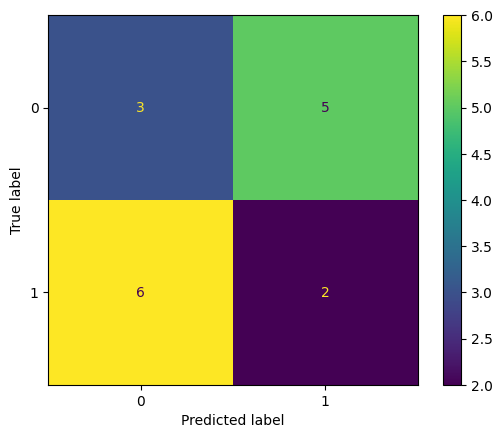

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


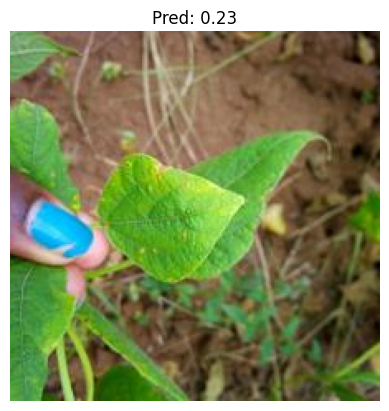

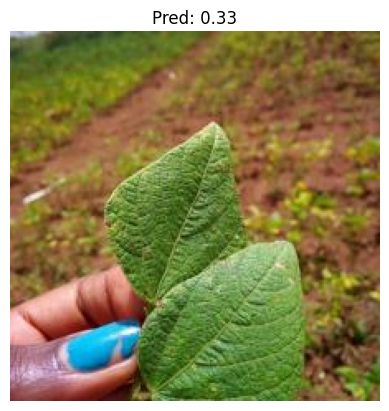

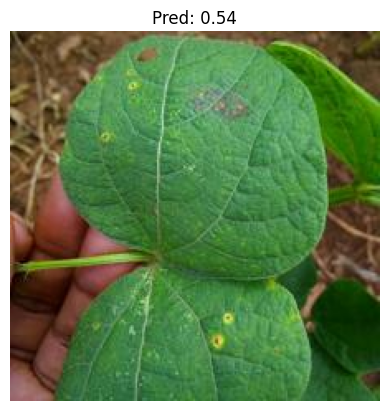

In [ ]:
# PROYECTO CNN ULTRA SIMPLE – GOOGLE COLAB
# Dataset: beans (Hugging Face)

# ===============================
# INSTALAR
# ===============================
!pip -q install tensorflow datasets scikit-learn matplotlib pillow

# ===============================
# IMPORTS
# ===============================
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from datasets import load_dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ===============================
# DATASET (beans, binario)
# ===============================
print("Cargando dataset beans...")
ds = load_dataset("beans", split="train")

BASE = "/content/beans"
os.makedirs(BASE+"/disease", exist_ok=True)
os.makedirs(BASE+"/healthy", exist_ok=True)

# Inspección segura de la etiqueta (labels o label)
for i, x in enumerate(ds):
    lbl = x.get('labels', x.get('label'))
    if lbl == 1 and i < 30:
        x['image'].resize((224,224)).save(f"{BASE}/disease/{i}.jpg")
    if lbl == 2 and i < 30:
        x['image'].resize((224,224)).save(f"{BASE}/healthy/{i}.jpg")
# ===============================
# GENERADORES
# ===============================
dg = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train = dg.flow_from_directory(BASE, target_size=(224,224), subset='training', class_mode='binary')
val   = dg.flow_from_directory(BASE, target_size=(224,224), subset='validation', class_mode='binary', shuffle=False)

# ===============================
# MODELO
# ===============================
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ===============================
# ENTRENAR
# ===============================
model.fit(train, validation_data=val, epochs=2)

# ===============================
# RESULTADOS
# ===============================
y_true = val.classes
y_pred = (model.predict(val) > 0.5).astype(int).ravel()
ConfusionMatrixDisplay(confusion_matrix(y_true,y_pred)).plot()
plt.show()

# ===============================
# 3 PREDICCIONES
# ===============================
imgs,_ = next(val)
preds = model.predict(imgs)
for i in range(3):
    plt.imshow(imgs[i])
    plt.title(f"Pred: {preds[i][0]:.2f}")
    plt.axis('off')
    plt.show()
